In [1]:
# W3D3: Decision Trees & Random Forests

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)

print("Libraries imported successfully!")

Libraries imported successfully!


In [2]:
# Load the Breast Cancer dataset

data = load_breast_cancer()

X = pd.DataFrame(data.data, columns=data.feature_names)
y = pd.Series(data.target, name="target")

print("Dataset loaded successfully!")
print("Features shape:", X.shape)
print("Target shape:", y.shape)

Dataset loaded successfully!
Features shape: (569, 30)
Target shape: (569,)


In [3]:
# Inspect the dataset

print("First 5 rows:")
display(X.head())

print("\nTarget distribution:")
print(y.value_counts())

print("\nTotal missing values:", X.isnull().sum().sum())

First 5 rows:


,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678



Target distribution:
target
1    357
0    212
Name: count, dtype: int64

Total missing values: 0


In [4]:
# Split data into training and testing sets

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training samples:", X_train.shape[0])
print("Testing samples:", X_test.shape[0])

Training samples: 455
Testing samples: 114


In [5]:
# Train the initial Decision Tree model

dt_model = DecisionTreeClassifier(
    random_state=42
)

dt_model.fit(X_train, y_train)

print("Decision Tree trained successfully!")

Decision Tree trained successfully!


In [6]:
# Make predictions

y_pred_dt = dt_model.predict(X_test)

# Calculate evaluation metrics

dt_accuracy = accuracy_score(y_test, y_pred_dt)
dt_precision = precision_score(y_test, y_pred_dt)
dt_recall = recall_score(y_test, y_pred_dt)
dt_f1 = f1_score(y_test, y_pred_dt)

print("Decision Tree Performance")
print("-------------------------")
print(f"Accuracy : {dt_accuracy:.4f}")
print(f"Precision: {dt_precision:.4f}")
print(f"Recall   : {dt_recall:.4f}")
print(f"F1 Score : {dt_f1:.4f}")

Decision Tree Performance
-------------------------
Accuracy : 0.9123
Precision: 0.9559
Recall   : 0.9028
F1 Score : 0.9286


In [7]:
# Compare training and testing accuracy

train_accuracy_dt = dt_model.score(X_train, y_train)
test_accuracy_dt = dt_model.score(X_test, y_test)

print("Decision Tree Accuracy")
print("----------------------")
print(f"Training Accuracy: {train_accuracy_dt:.4f}")
print(f"Testing Accuracy : {test_accuracy_dt:.4f}")

Decision Tree Accuracy
----------------------
Training Accuracy: 1.0000
Testing Accuracy : 0.9123


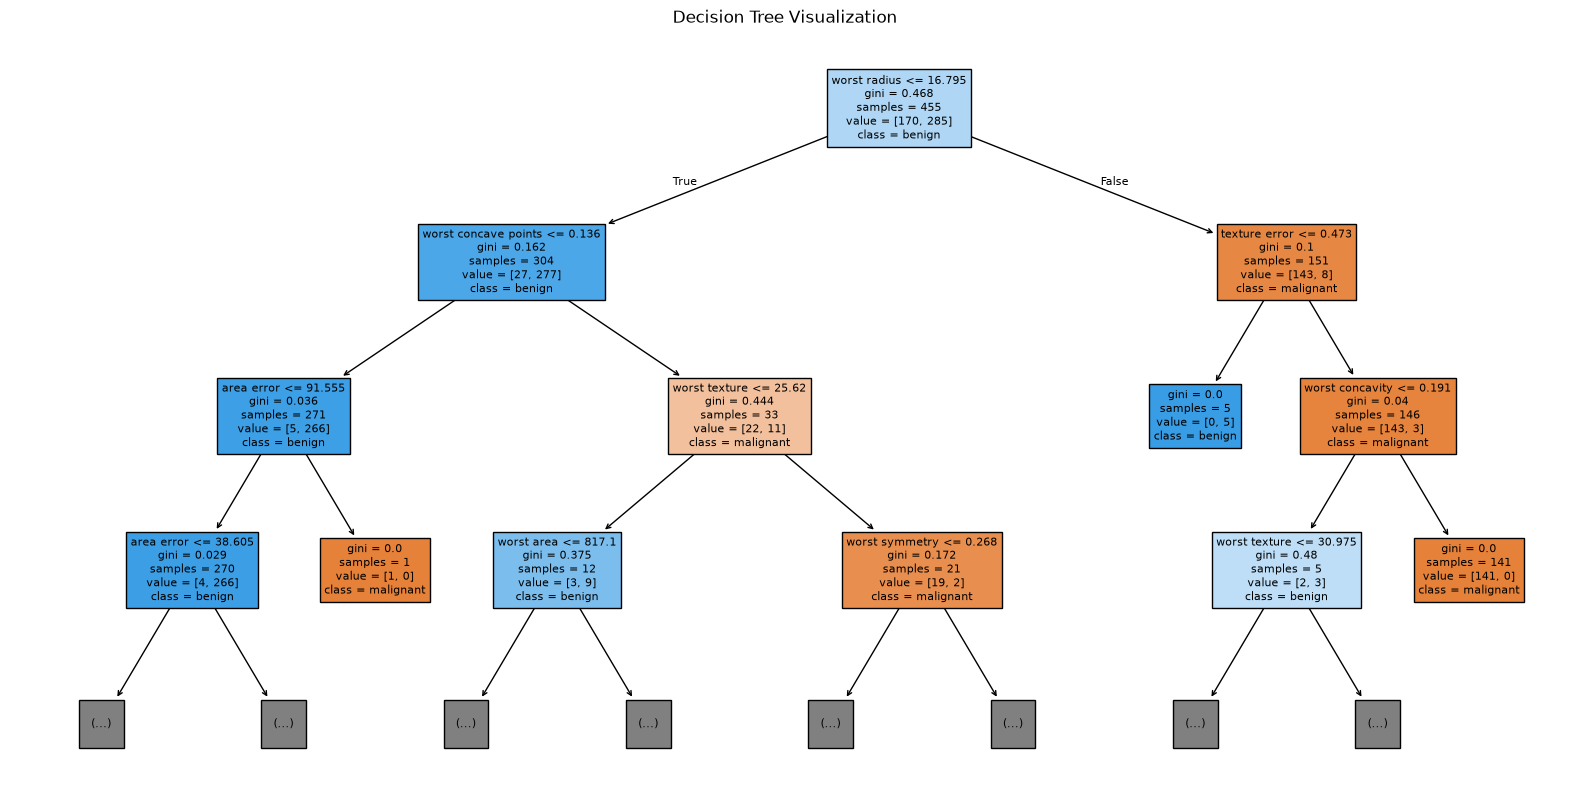

In [8]:
# Visualize the Decision Tree

plt.figure(figsize=(20, 10))

plot_tree(
    dt_model,
    feature_names=data.feature_names,
    class_names=data.target_names,
    filled=True,
    max_depth=3
)

plt.title("Decision Tree Visualization")
plt.show()

In [9]:
# Create a tuned Decision Tree to reduce overfitting

tuned_dt = DecisionTreeClassifier(
    max_depth=5,
    min_samples_split=10,
    min_samples_leaf=5,
    random_state=42
)

tuned_dt.fit(X_train, y_train)

y_pred_tuned = tuned_dt.predict(X_test)

print("Tuned Decision Tree trained successfully!")

Tuned Decision Tree trained successfully!


In [10]:
# Evaluate the tuned Decision Tree

tuned_accuracy = accuracy_score(y_test, y_pred_tuned)
tuned_precision = precision_score(y_test, y_pred_tuned)
tuned_recall = recall_score(y_test, y_pred_tuned)
tuned_f1 = f1_score(y_test, y_pred_tuned)

print("Tuned Decision Tree Performance")
print("--------------------------------")
print(f"Training Accuracy: {tuned_dt.score(X_train, y_train):.4f}")
print(f"Testing Accuracy : {tuned_accuracy:.4f}")
print(f"Precision        : {tuned_precision:.4f}")
print(f"Recall           : {tuned_recall:.4f}")
print(f"F1 Score         : {tuned_f1:.4f}")

Tuned Decision Tree Performance
--------------------------------
Training Accuracy: 0.9758
Testing Accuracy : 0.9211
Precision        : 0.9437
Recall           : 0.9306
F1 Score         : 0.9371


In [11]:
# Train the Random Forest model

rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

rf_model.fit(X_train, y_train)

y_pred_rf = rf_model.predict(X_test)

print("Random Forest trained successfully!")

Random Forest trained successfully!


In [12]:
# Evaluate Random Forest

rf_accuracy = accuracy_score(y_test, y_pred_rf)
rf_precision = precision_score(y_test, y_pred_rf)
rf_recall = recall_score(y_test, y_pred_rf)
rf_f1 = f1_score(y_test, y_pred_rf)

print("Random Forest Performance")
print("-------------------------")
print(f"Training Accuracy: {rf_model.score(X_train, y_train):.4f}")
print(f"Testing Accuracy : {rf_accuracy:.4f}")
print(f"Precision        : {rf_precision:.4f}")
print(f"Recall           : {rf_recall:.4f}")
print(f"F1 Score         : {rf_f1:.4f}")

Random Forest Performance
-------------------------
Training Accuracy: 1.0000
Testing Accuracy : 0.9561
Precision        : 0.9589
Recall           : 0.9722
F1 Score         : 0.9655


In [14]:
# Generate predictions from the original Decision Tree
y_pred_dt = dt_model.predict(X_test)

# Generate predictions from the tuned Decision Tree
y_pred_tuned = tuned_dt.predict(X_test)

# Generate predictions from Random Forest
y_pred_rf = rf_model.predict(X_test)

# Compare model performance
comparison = pd.DataFrame({
    "Model": ["Decision Tree", "Tuned Decision Tree", "Random Forest"],
    "Accuracy": [
        accuracy_score(y_test, y_pred_dt),
        accuracy_score(y_test, y_pred_tuned),
        accuracy_score(y_test, y_pred_rf)
    ],
    "Precision": [
        precision_score(y_test, y_pred_dt),
        precision_score(y_test, y_pred_tuned),
        precision_score(y_test, y_pred_rf)
    ],
    "Recall": [
        recall_score(y_test, y_pred_dt),
        recall_score(y_test, y_pred_tuned),
        recall_score(y_test, y_pred_rf)
    ],
    "F1 Score": [
        f1_score(y_test, y_pred_dt),
        f1_score(y_test, y_pred_tuned),
        f1_score(y_test, y_pred_rf)
    ]
})

display(comparison)

,Model,Accuracy,Precision,Recall,F1 Score
0,Decision Tree,0.912281,0.955882,0.902778,0.928571
1,Tuned Decision Tree,0.921053,0.943662,0.930556,0.937063
2,Random Forest,0.956140,0.958904,0.972222,0.965517


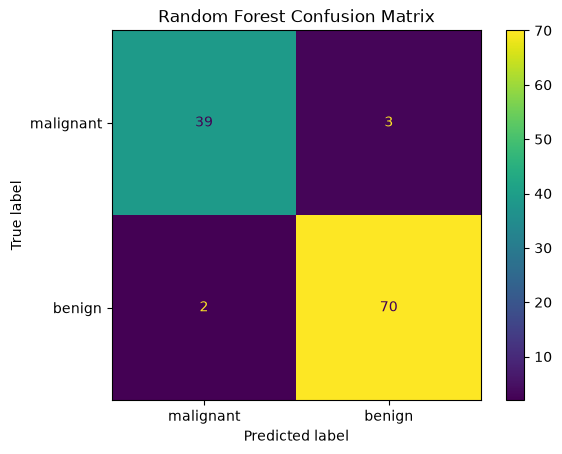

In [15]:
from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred_rf,
    display_labels=data.target_names
)

plt.title("Random Forest Confusion Matrix")
plt.show()

In [16]:
feature_importance = pd.Series(
    rf_model.feature_importances_,
    index=data.feature_names
).sort_values(ascending=False)

print("Top 10 Important Features:")
display(feature_importance.head(10))

Top 10 Important Features:


worst area              0.140016
worst concave points    0.129530
worst radius            0.097696
mean concave points     0.090885
worst perimeter         0.072226
mean perimeter          0.069574
mean radius             0.068676
mean concavity          0.057638
mean area               0.049172
worst concavity         0.034340
dtype: float64

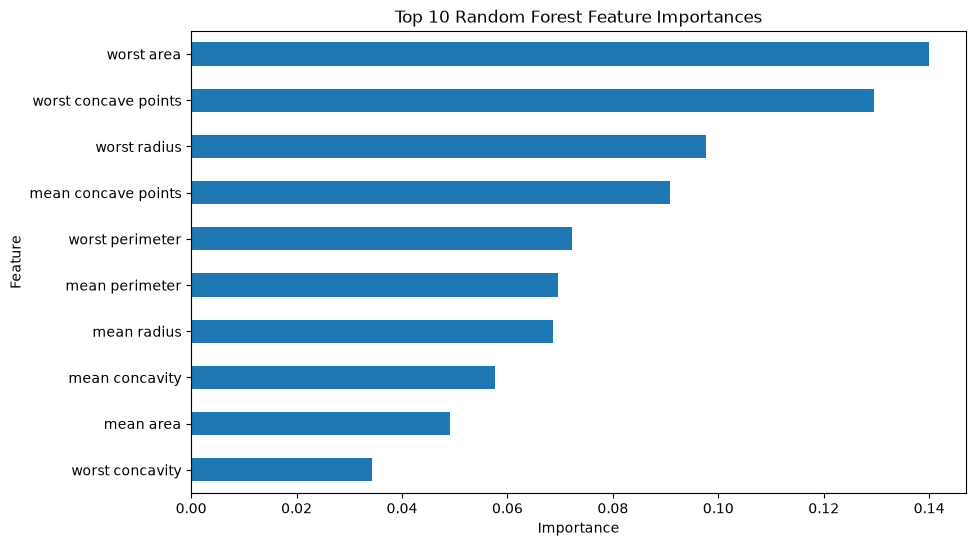

In [17]:
feature_importance.head(10).sort_values().plot(
    kind="barh",
    figsize=(10, 6)
)

plt.title("Top 10 Random Forest Feature Importances")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.show()

In [18]:
from sklearn.metrics import classification_report

print("Random Forest Classification Report")
print("------------------------------------")
print(
    classification_report(
        y_test,
        y_pred_rf,
        target_names=data.target_names
    )
)

Random Forest Classification Report
------------------------------------
              precision    recall  f1-score   support

   malignant       0.95      0.93      0.94        42
      benign       0.96      0.97      0.97        72

    accuracy                           0.96       114
   macro avg       0.96      0.95      0.95       114
weighted avg       0.96      0.96      0.96       114



## Conclusion

The Decision Tree and Random Forest models were successfully implemented using the Breast Cancer dataset.

The initial Decision Tree was evaluated for accuracy, precision, recall, and F1-score. The training and testing performance were compared to identify possible overfitting.

The Decision Tree was then tuned using `max_depth`, `min_samples_split`, and `min_samples_leaf` to control model complexity and improve generalization.

A Random Forest classifier was also implemented and compared with both the original and tuned Decision Tree models. The Random Forest performance was evaluated using classification metrics and a confusion matrix.

Feature importance was analyzed to identify the most influential features used by the Random Forest model.

Overall, Random Forest provides a robust ensemble approach, while Decision Trees are easier to interpret and visualize.